# IFTAS Bad Actor Matching

Checking our snapshot against IFTAS blocklists and matching known bad actors.

Useful References
- IFTAS Community Library: https://about.iftas.org/trust-safety-services/iftas-community-library/
- IFTAS Curated Deny Lists: https://about.iftas.org/library/denylist-resources/

In [10]:
# import libraries
import sys
import os
import logging
import powerlaw
import igraph as ig
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import networkx as nx
from collections import Counter
from adjustText import adjust_text

# Add the parent directory to sys.path to enable imports from analysis subfolder
sys.path.append(os.path.abspath(".."))

# import functions
from load_graph import load_graph
from fit_degrees_to_power_law import fit_degrees_to_power_law
from fit_degrees_to_power_law import fit_degrees_to_power_law_files
from median_degree_by_depth import median_degree_by_depth
from top_n_no_share_hostnames import no_share_hostnames

In [2]:
# nodes, edges, graph
nodes = r"../../data_sample_snapshots/snapshot-2026-07-04-030017-nodes.parquet"
edges = r"../../data_sample_snapshots/snapshot-2026-07-04-030017-edges.parquet"
G = load_graph(nodes, edges)

### Degree Distribution

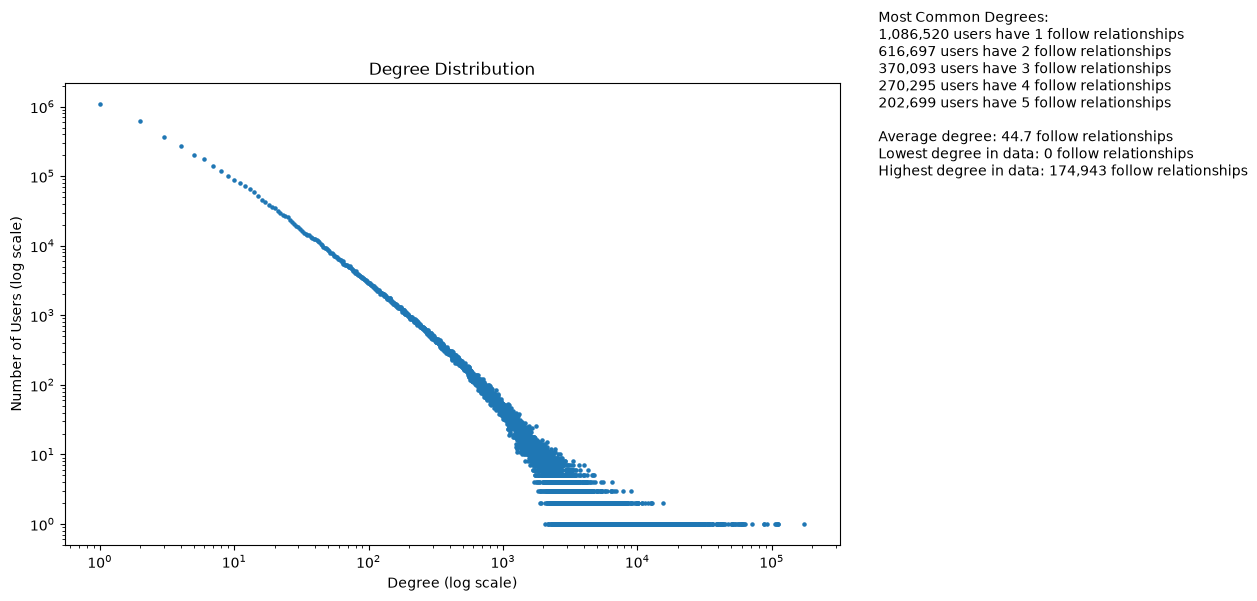

In [32]:
# Degree Distribution
# Example Reference: https://networkx.org/documentation/networkx-2.5/auto_examples/drawing/plot_degree_histogram.html 

degrees = G.degree()
degree_count = Counter(degrees)

degree = list(degree_count.keys())
count = list(degree_count.values())

plt.figure(figsize=(10, 6))
plt.scatter(degree, count, s=5)

plt.xscale("log")
plt.yscale("log")

plt.title("Degree Distribution")
plt.xlabel("Degree (log scale)")
plt.ylabel("Number of Users (log scale)")

# Side text with top degrees
text = "Most Common Degrees:\n"

for degree, users in degree_count.most_common(5): # Currently at top 5 most common
    text += f"{users:,} users have {degree} follow relationships\n"

# Average Degree plus highests/lowest degrees
# "Median Degree by Depth Distribution" may be a better future metric
average_degree = sum(degrees) / len(degrees)
lowest_degree = min(degrees)
highest_degree = max(degrees)

text += f"\nAverage degree: {average_degree:.1f} follow relationships"
text += f"\nLowest degree in data: {lowest_degree} follow relationships"
text += f"\nHighest degree in data: {highest_degree:,} follow relationships"

plt.text(
    1.05, 0.8,
    text,
    transform=plt.gca().transAxes
)

plt.show()

### IFTAS CARIAD Denylist Matching
https://about.iftas.org/library/iftas-cariad-denylist/

In [111]:
# iftas CARIAD denylist matching

iftas_denylist = pd.read_csv(r"iftas_bad_actor_resources/iftas-cariad-latest-june-2026.csv")
denylist = set(iftas_denylist["#domain"].dropna().str.lower())

matched_nodes  = []

for node in G.vs:
    if not pd.isna(node["hostname"]) and node["hostname"] in denylist:
        matched_nodes.append(node)
        
print("Nodes matched with IFTAS CARIAD denylist:", len(matched_nodes))

Nodes matched with IFTAS CARIAD denylist: 486204


In [112]:
# top users in each platform within the matched set

top_users_by_platform_followers = {}
top_users_by_platform_degree = {}

for node in matched_nodes:
    hostname = node["hostname"]
    degree = G.degree(node.index)

    if pd.isna(node["followers_count"]):
        continue

    # top follower count swap
    if hostname not in top_users_by_platform_followers:
        top_users_by_platform_followers[hostname] = node
    elif node["followers_count"] > top_users_by_platform_followers[hostname]["followers_count"]:
        top_users_by_platform_followers[hostname] = node

    # top degree count check
    if hostname not in top_users_by_platform_degree:
        top_users_by_platform_degree[hostname] = node
    elif degree > G.degree(top_users_by_platform_degree[hostname].index):
        top_users_by_platform_degree[hostname] = node


In [113]:
# sort the platforms by the number of followers of their top user

follower_count_items = []

for hostname, node in top_users_by_platform_followers.items():
    follower_count_items.append((hostname, node["preferred_username"], node["followers_count"]))

follower_count_items.sort(key=lambda x: x[2], reverse=True) # sort by followers count in descending order

for hostname, username, followers in follower_count_items:
    print(hostname, username, followers)


threads.net barackobama 10086068.0
pawoo.net pawoo_support 646896.0
pravda.me admin 143625.0
baraag.net curator 102637.0
mstdn.jp sft 93454.0
alive.bar admin 19230.0
poa.st Jim 13700.0
spinster.xyz spinster 11016.0
kiwifarms.cc josh 4956.0
cum.salon nimt 4308.0
tickler.cc BruceShaw 4302.0
gameliberty.club matrix 4267.0
aethy.com ComfyBrat 2743.0
9kb.me breakingnewsat9kb 2647.0
pubeurope.com europesays 2393.0
eveningzoo.club Humpleupagus 2130.0
gimmeloli.cc fute774 2047.0
truthsocial.co.in gopi 2023.0
cawfee.club admin 1720.0
gegenstimme.tv shlomo_finkelstein 1713.0
ghetti.monster lolibot 1629.0
shitpost.cloud Hoss 1615.0
freeatlantis.com icare4america 1604.0
noauthority.social SiRrogueKnight 1586.0
social.freysa.ai freysa 1464.0
nicecrew.digital n3f_X 1462.0
electroverse.tech ladefuchs 1380.0
rape.pet ulith 1359.0
shitposter.world sun 1291.0
strelizia.net zero 1243.0
varishangout.net Halo 1226.0
gearlandia.haus mikuphile 1175.0
fsebugoutzone.org p 1105.0
wolfgirl.bar mkultra 1093.0
map

In [114]:
# sort the platforms by degree of their top user

degree_count_items = []

for hostname, node in top_users_by_platform_degree.items():
    degree_count_items.append((hostname, node["preferred_username"],G.degree(node.index)))

degree_count_items.sort(key=lambda x: x[2], reverse=True) # sort by degree count in descending order

for hostname, username, degree in degree_count_items:
    print(hostname, username, degree)

pawoo.net Macroneon 35878
bae.st Owl 29683
spinster.xyz spinster 10310
mstdn.jp Bug 9569
baraag.net curator 9491
merovingian.club freepatriot 7349
gameliberty.club matrix 5405
eveningzoo.club Humpleupagus 5350
threads.net potus46archive 5166
freeatlantis.com icare4america 4949
fsebugoutzone.org p 4096
kiwifarms.cc superfren 4077
noauthority.social SiRrogueKnight 3812
varishangout.net ungatox3 3586
mapsupport.de Olmill 3461
alive.bar lianghuan 2750
poa.st graf 2678
9kb.me breakingnewsat9kb 2653
shitpost.cloud Hoss 2498
pravda.me rt_russian 2302
gearlandia.haus mikuphile 1940
gimmeloli.cc fute774 1894
cawfee.club grips 1843
truthsocial.co.in gopi 1657
shota.house RehnyNytes256 1581
loli.church Wiz 1559
social.freysa.ai freysa 1464
rape.pet ulith 1464
croquis.moe dotkwa 1451
decayable.ink Doll 1415
ryona.agency mint 1359
shitposter.world sun 1352
ghetti.monster Mossakart 1311
liberdon.com Liberty4Masses 1184
electroverse.tech ladefuchs 1140
wolfgirl.bar mkultra 1128
clubcyberia.co crunklo

### IFTAS CARIAD Denylist Graphing

In [115]:
top_indices = set()
for node in top_users_by_platform_degree.values():
    top_indices.add(node.index)

matched_indices = set()
for node in matched_nodes:
    matched_indices.add(node.index)

max_gray_per_top_account = 100 # limit the num of gray accounts per top account 

gray_indices = set()
for top_index in top_indices:
    neighbors = G.neighbors(top_index, mode="all")

    denylisted_neighbors = []
    for neighbor_index in neighbors:
        if neighbor_index in matched_indices and neighbor_index not in top_indices:
            denylisted_neighbors.append(neighbor_index)

    # Keep the most connected grey accounts
    denylisted_neighbors.sort(key=lambda index: degrees[index],reverse=True)
    gray_indices.update(denylisted_neighbors[:max_gray_per_top_account])

G.vs["top_denylist_account"] = False

for index in top_indices:
    G.vs[index]["top_denylist_account"] = True
    
selected_vertices = list(top_indices | gray_indices)
denylist_graph = G.induced_subgraph(selected_vertices)

degrees_in_subgraph = []
for original_index in selected_vertices:
    degrees_in_subgraph.append(degrees[original_index])
    
denylist_graph.vs["degree"] = degrees_in_subgraph

print("Top accounts:", len(top_indices))
print("Other denylisted accounts:", len(gray_indices))
print("Displayed nodes:", denylist_graph.vcount())
print("Displayed edges:", denylist_graph.ecount())


Top accounts: 67
Other denylisted accounts: 2413
Displayed nodes: 2480
Displayed edges: 86244


In [119]:
# layout and coordinates
layout = denylist_graph.layout_fruchterman_reingold(
    niter=1000,
    start_temp=5
)

coordinates = np.asarray(layout.coords)
components = denylist_graph.components(mode="weak")
largest_component_index = max(
    range(len(components)),
    key=lambda i: len(components[i])
)

main_nodes = list(components[largest_component_index])
main_center = coordinates[main_nodes].mean(axis=0)

# compress the graph (push outliers in)
cluster_scale = 2.5
coordinates[main_nodes] = (
    main_center
    + (coordinates[main_nodes] - main_center) * cluster_scale
)
compression = 0.25

for component_index, component in enumerate(components):
    if component_index == largest_component_index:
        continue

    component_nodes = list(component)
    component_center = coordinates[component_nodes].mean(axis=0)
    offset = component_center - main_center
    coordinates[component_nodes] -= offset * (1 - compression)

x = coordinates[:, 0]
y = coordinates[:, 1]

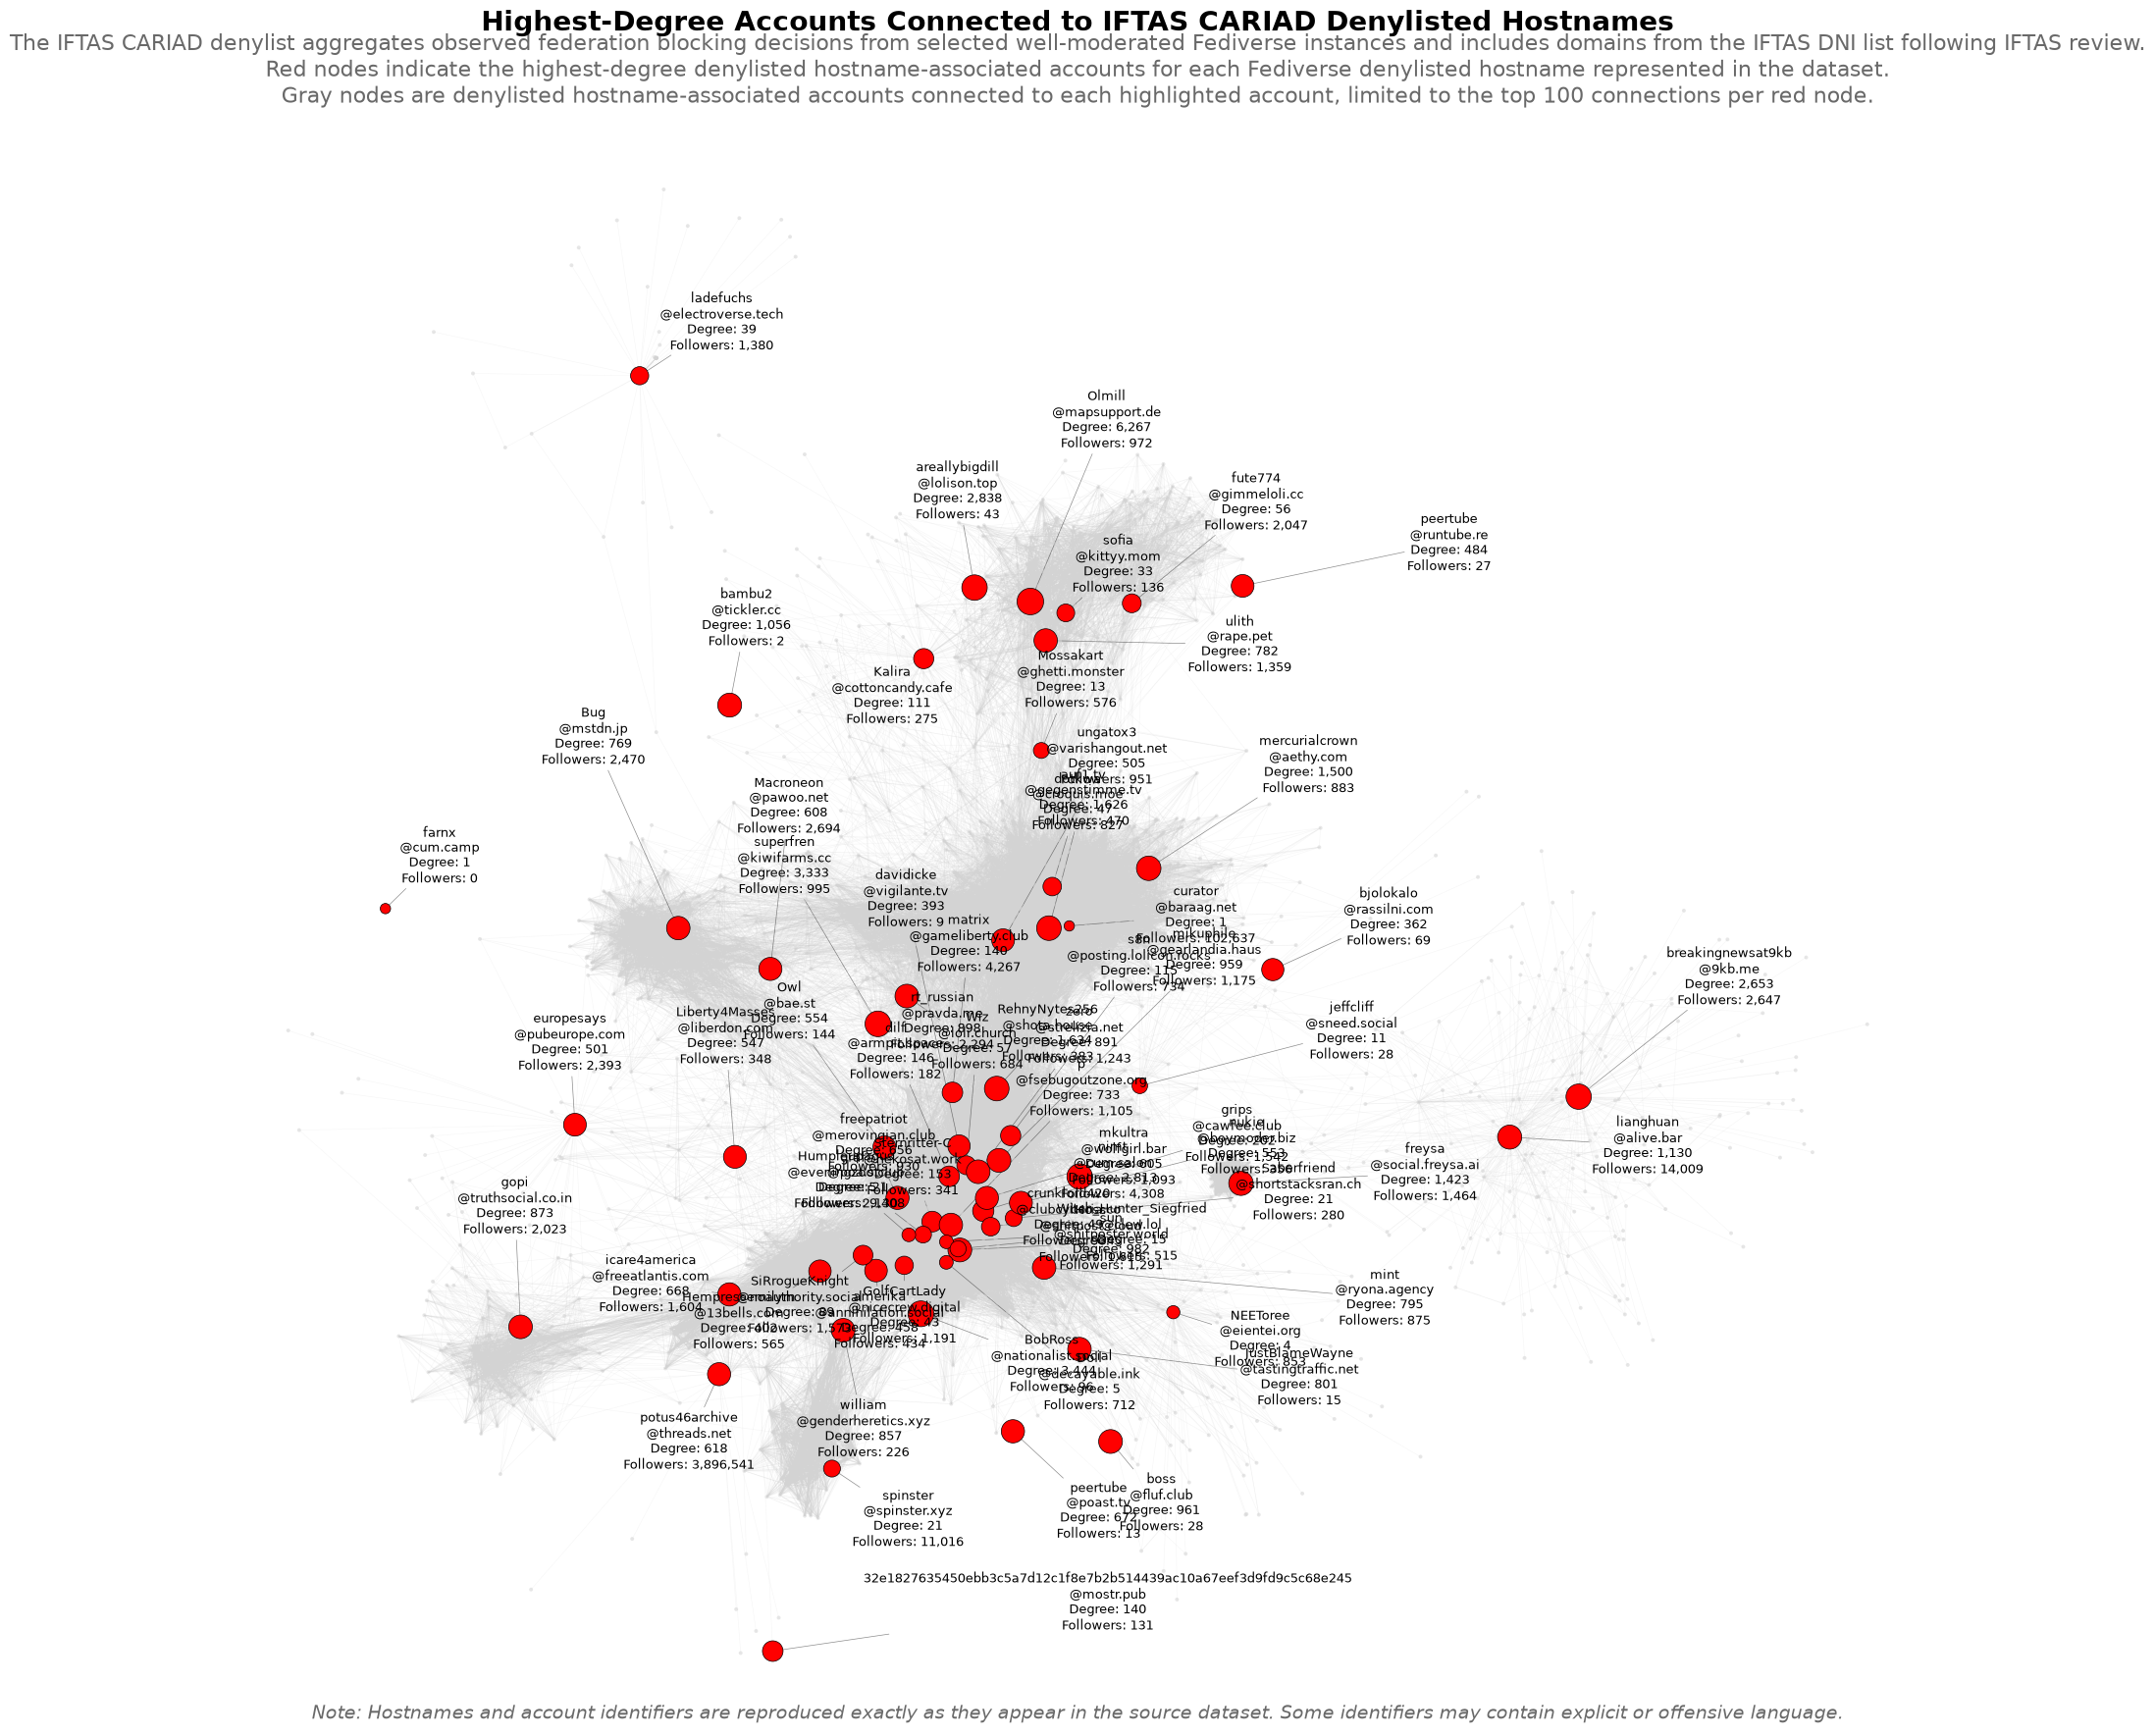

In [118]:
# nodes and sizes

red_nodes = []
for vertex in denylist_graph.vs:
    if vertex["top_denylist_account"]:
        red_nodes.append(vertex.index)
    
gray_nodes = []
for vertex in denylist_graph.vs:
    if not vertex["top_denylist_account"]:
        gray_nodes.append(vertex.index)

red_sizes = []
base_node_size = 30
degree_scale = 40

for index in red_nodes:
    degree = denylist_graph.vs[index]["degree"]
    # scale node size logarithmically by graph degree
    size = base_node_size + np.log1p(degree) * degree_scale
    red_sizes.append(size)

plt.figure(figsize=(18, 18))

# draw edges first
for edge in denylist_graph.es:
    source, target = edge.tuple
    plt.plot(
        [x[source], x[target]],
        [y[source], y[target]],
        color="lightgray",
        alpha=0.20,
        linewidth=0.4,
        zorder=1
    )

# draw small grey accounts behind the red ones
plt.scatter(
    x[gray_nodes],
    y[gray_nodes],
    s=8,
    color="lightgray",
    alpha=0.55,
    edgecolors="none",
    zorder=2
)

plt.scatter(
    x[red_nodes],
    y[red_nodes],
    s=red_sizes,
    color="red",
    edgecolors="black",
    linewidths=0.5,
    zorder=3
)

texts = []

# labels 
for index in red_nodes:
    vertex = denylist_graph.vs[index]

    username = vertex["preferred_username"]
    degree = vertex["degree"]
    followers = vertex["followers_count"]
    hostname = vertex["hostname"]

    if pd.isna(followers):
        followers_text = "unknown"
    else:
        followers_text = f"{int(followers):,}"

    if pd.isna(hostname) or hostname == "":
        account_name = str(username)
    else:
        account_name = f"{username}@{hostname}"

    label = (
        f"{username}\n"
        f"@{hostname}\n"
        f"Degree: {degree:,}\n"
        f"Followers: {followers_text}"
    )

    text = plt.text(
        x[index],
        y[index],
        label,
        fontsize=9,
        ha="left",
        va="bottom",
        zorder=4
    )

    texts.append(text)

adjust_text(
    texts,
    x=[x[index] for index in red_nodes],
    y=[y[index] for index in red_nodes],
    ax=plt.gca(),
    expand=(1.15, 1.3),
    force_text=(0.5, 0.8),
    force_static=(0.3, 0.5),
    force_pull=(0.02, 0.02),
    max_move=(30, 30),
    pull_threshold=15,
    arrowprops=dict(
        arrowstyle="-",
        linewidth=0.5,
        alpha=0.45
    )
)

plt.suptitle(
    "Highest-Degree Accounts Connected to IFTAS CARIAD Denylisted Hostnames",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

plt.title(         
    "The IFTAS CARIAD denylist aggregates observed federation blocking decisions from selected well-moderated Fediverse instances and includes domains from the IFTAS DNI list following IFTAS review.\n"         
    "Red nodes indicate the highest-degree denylisted hostname-associated accounts for each Fediverse denylisted hostname represented in the dataset.\n" 
    "Gray nodes are denylisted hostname-associated accounts connected to each highlighted account, limited to the top 100 connections per red node.",
    fontsize=16,
    color="dimgray",
    pad=10
)

fig = plt.gcf()
fig.text(
    0.5,
    0.01,
    "Note: Hostnames and account identifiers are reproduced exactly as they appear in the source dataset."
    " Some identifiers may contain explicit or offensive language.",
    ha="center",
    va="bottom",
    fontsize=14,
    color="dimgray",
    style="italic",
)

plt.axis("off")
plt.tight_layout()
plt.show()

### IFTAS DNI List Matching
https://about.iftas.org/library/iftas-dni-list/

In [91]:
# iftas DO NOT INTERACT denylist matching

iftas_denylist = pd.read_csv(r"iftas_bad_actor_resources/iftas-dni-latest-july-2026.csv")
denylist = set(iftas_denylist["#domain"].dropna().str.lower())

matched_nodes  = []

for node in G.vs:
    if not pd.isna(node["hostname"]) and node["hostname"] in denylist:
        matched_nodes.append(node)
        
print("Nodes matched with IFTAS DNI denylist:", len(matched_nodes))

Nodes matched with IFTAS DNI denylist: 278751


In [92]:
# BUT FOR DNI -- top users in each platform within the matched set

top_users_by_platform_followers = {}
top_users_by_platform_degree = {}

for node in matched_nodes:
    hostname = node["hostname"]
    degree = G.degree(node.index)

    if pd.isna(node["followers_count"]):
        continue

    # top follower count swap
    if hostname not in top_users_by_platform_followers:
        top_users_by_platform_followers[hostname] = node
    elif node["followers_count"] > top_users_by_platform_followers[hostname]["followers_count"]:
        top_users_by_platform_followers[hostname] = node

    # top degree count check
    if hostname not in top_users_by_platform_degree:
        top_users_by_platform_degree[hostname] = node
    elif degree > G.degree(top_users_by_platform_degree[hostname].index):
        top_users_by_platform_degree[hostname] = node

In [93]:
# BUT FOR DNI-- sort the platforms by the number of followers of their top user

follower_count_items = []

for hostname, node in top_users_by_platform_followers.items():
    follower_count_items.append((hostname, node["preferred_username"], node["followers_count"]))

follower_count_items.sort(key=lambda x: x[2], reverse=True) # sort by followers count in descending order

for hostname, username, followers in follower_count_items:
    print(hostname, username, followers)

pawoo.net pawoo_support 646896.0
pravda.me admin 143625.0
baraag.net curator 102637.0
poa.st Jim 13700.0
kiwifarms.cc josh 4956.0
cum.salon nimt 4308.0
gameliberty.club matrix 4267.0
aethy.com ComfyBrat 2743.0
eveningzoo.club Humpleupagus 2130.0
gimmeloli.cc fute774 2047.0
cawfee.club admin 1720.0
gegenstimme.tv shlomo_finkelstein 1713.0
shitpost.cloud Hoss 1615.0
freeatlantis.com icare4america 1604.0
noauthority.social SiRrogueKnight 1586.0
nicecrew.digital n3f_X 1462.0
rape.pet ulith 1359.0
varishangout.net Halo 1226.0
merovingian.club freepatriot 934.0
clew.lol Tony 895.0
eientei.org lina 876.0
ryona.agency mint 875.0
croquis.moe dotkwa 827.0
loli.church Wiz 684.0
shota.house Gatitasecsii 599.0
nekosat.work Cocoa 598.0
13bells.com Hempressemilym 565.0
cottoncandy.cafe Relic 479.0
boymoder.biz nukie 356.0
poast.tv randbot_channel 224.0
armpit.space dilf 182.0
nationalist.social NateHiggers1488 156.0
bae.st Owl 144.0
kittyy.mom sofia 136.0
rassilni.com bjolokalo 69.0
runtube.re canard

In [94]:
# BUT FOR DNI-- sort the platforms by degree of their top user

degree_count_items = []

for hostname, node in top_users_by_platform_degree.items():
    degree_count_items.append((hostname, node["preferred_username"],G.degree(node.index)))

degree_count_items.sort(key=lambda x: x[2], reverse=True) # sort by degree count in descending order

for hostname, username, degree in degree_count_items:
    print(hostname, username, degree)

pawoo.net Macroneon 35878
bae.st Owl 29683
baraag.net curator 9491
merovingian.club freepatriot 7349
gameliberty.club matrix 5405
eveningzoo.club Humpleupagus 5350
freeatlantis.com icare4america 4949
kiwifarms.cc superfren 4077
noauthority.social SiRrogueKnight 3812
varishangout.net ungatox3 3586
poa.st graf 2678
shitpost.cloud Hoss 2498
pravda.me rt_russian 2302
gimmeloli.cc fute774 1894
cawfee.club grips 1843
shota.house RehnyNytes256 1581
loli.church Wiz 1559
rape.pet ulith 1464
croquis.moe dotkwa 1451
ryona.agency mint 1359
aethy.com mercurialcrown 933
13bells.com Hempressemilym 902
nicecrew.digital GolfCartLady 871
eientei.org NEEToree 855
boymoder.biz nukie 779
clew.lol Witch_Hunter_Siegfried 604
armpit.space dilf 569
cum.salon nimt 490
nekosat.work Sternritter-C 431
kittyy.mom sofia 337
cottoncandy.cafe Kalira 296
nationalist.social BobRoss 253
rassilni.com bjolokalo 197
poast.tv peertube 67
runtube.re peertube 59
gegenstimme.tv auf1.tv 23
vigilante.tv davidicke 10


### IFTAS DNI Denylist Graphing

In [95]:
# BUT FOR DNI

top_indices = set()
for node in top_users_by_platform_degree.values():
    top_indices.add(node.index)

matched_indices = set()
for node in matched_nodes:
    matched_indices.add(node.index)

max_gray_per_top_account = 100 # limit the num of gray accounts per top account 

gray_indices = set()
for top_index in top_indices:
    neighbors = G.neighbors(top_index, mode="all")

    denylisted_neighbors = []
    for neighbor_index in neighbors:
        if neighbor_index in matched_indices and neighbor_index not in top_indices:
            denylisted_neighbors.append(neighbor_index)

    # Keep the most connected grey accounts
    denylisted_neighbors.sort(key=lambda index: degrees[index],reverse=True)
    gray_indices.update(denylisted_neighbors[:max_gray_per_top_account])

G.vs["top_denylist_account"] = False

for index in top_indices:
    G.vs[index]["top_denylist_account"] = True
    
selected_vertices = list(top_indices | gray_indices)
denylist_graph = G.induced_subgraph(selected_vertices)

degrees_in_subgraph = []
for original_index in selected_vertices:
    degrees_in_subgraph.append(degrees[original_index])
    
denylist_graph.vs["degree"] = degrees_in_subgraph

print("Top accounts:", len(top_indices))
print("Other denylisted accounts:", len(gray_indices))
print("Displayed nodes:", denylist_graph.vcount())
print("Displayed edges:", denylist_graph.ecount())

Top accounts: 37
Other denylisted accounts: 1533
Displayed nodes: 1570
Displayed edges: 54889


In [96]:
# BUT FOR DNI-- layout and coordinates
layout = denylist_graph.layout_fruchterman_reingold(
    niter=1000,
    start_temp=5
)

coordinates = np.asarray(layout.coords)
components = denylist_graph.components(mode="weak")
largest_component_index = max(
    range(len(components)),
    key=lambda i: len(components[i])
)

main_nodes = list(components[largest_component_index])
main_center = coordinates[main_nodes].mean(axis=0)

# compress the graph (push outliers in)
cluster_scale = 2.5
coordinates[main_nodes] = (
    main_center
    + (coordinates[main_nodes] - main_center) * cluster_scale
)
compression = 0.25

for component_index, component in enumerate(components):
    if component_index == largest_component_index:
        continue

    component_nodes = list(component)
    component_center = coordinates[component_nodes].mean(axis=0)
    offset = component_center - main_center
    coordinates[component_nodes] -= offset * (1 - compression)

x = coordinates[:, 0]
y = coordinates[:, 1]

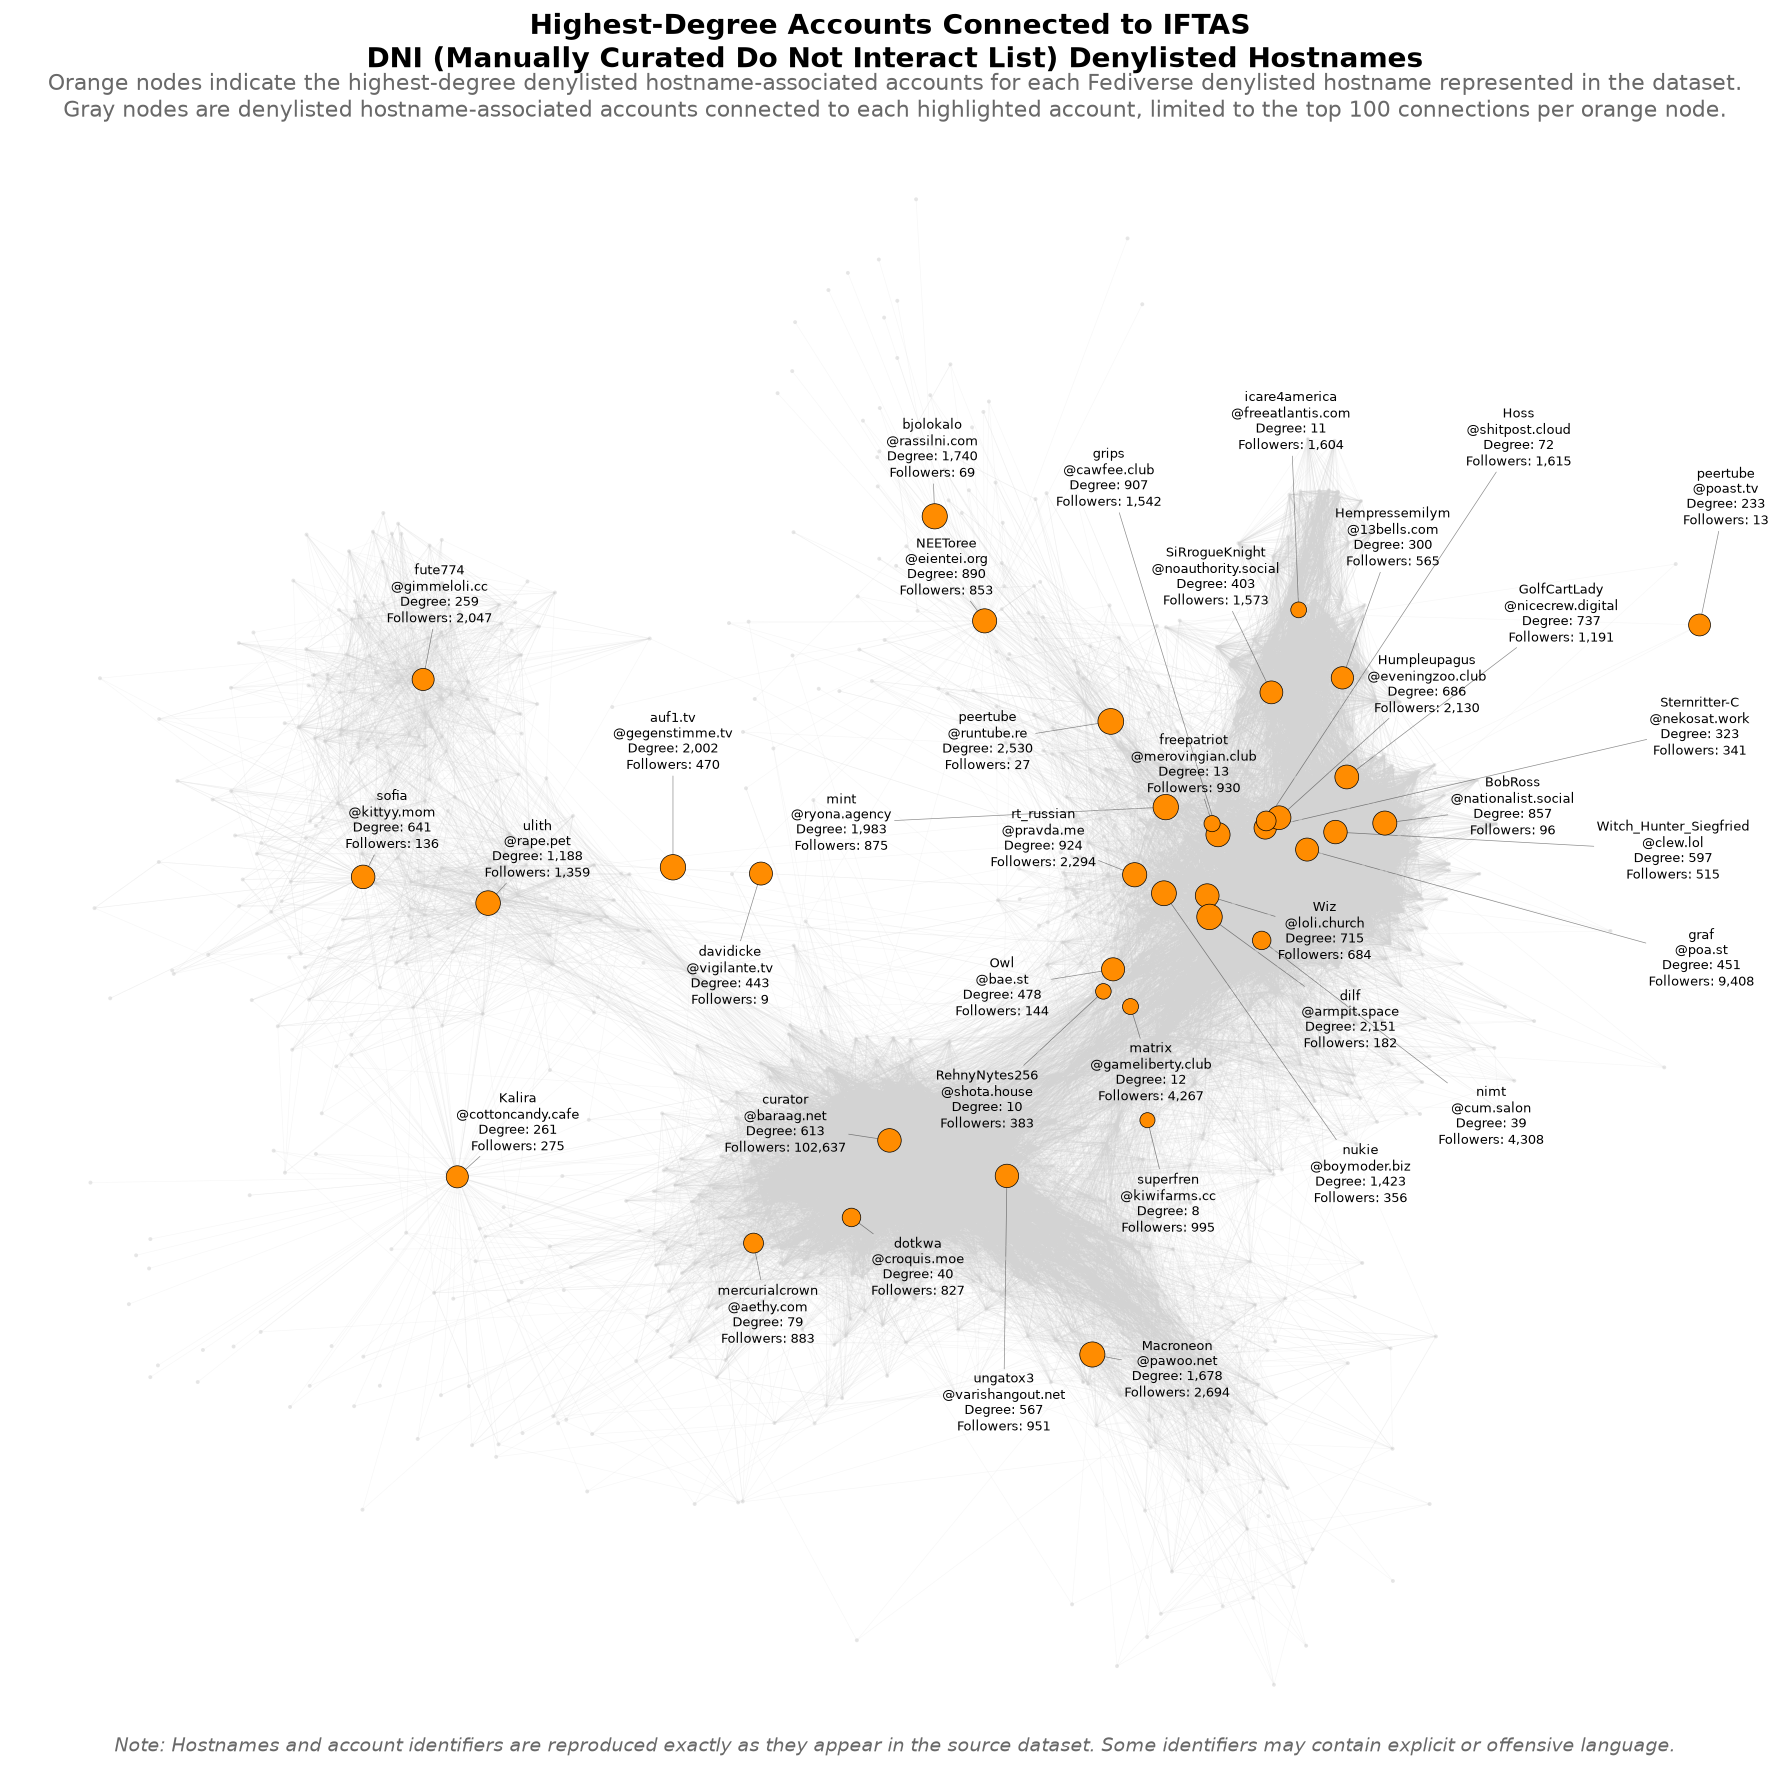

In [98]:
# BUT FOR DNI-- nodes and sizes

orange_nodes = []
for vertex in denylist_graph.vs:
    if vertex["top_denylist_account"]:
        orange_nodes.append(vertex.index)
    
gray_nodes = []
for vertex in denylist_graph.vs:
    if not vertex["top_denylist_account"]:
        gray_nodes.append(vertex.index)

orange_sizes = []
base_node_size = 30
degree_scale = 40

for index in orange_nodes:
    degree = denylist_graph.vs[index]["degree"]
    # scale node size logarithmically by graph degree
    size = base_node_size + np.log1p(degree) * degree_scale
    orange_sizes.append(size)

plt.figure(figsize=(18, 18))

# draw edges first
for edge in denylist_graph.es:
    source, target = edge.tuple
    plt.plot(
        [x[source], x[target]],
        [y[source], y[target]],
        color="lightgray",
        alpha=0.20,
        linewidth=0.4,
        zorder=1
    )

# draw small grey accounts behind the red ones
plt.scatter(
    x[gray_nodes],
    y[gray_nodes],
    s=8,
    color="lightgray",
    alpha=0.55,
    edgecolors="none",
    zorder=2
)

plt.scatter(
    x[orange_nodes],
    y[orange_nodes],
    s=orange_sizes,
    color="darkorange",
    edgecolors="black",
    linewidths=0.5,
    zorder=3
)

texts = []

# labels 
for index in orange_nodes:
    vertex = denylist_graph.vs[index]

    username = vertex["preferred_username"]
    degree = vertex["degree"]
    followers = vertex["followers_count"]
    hostname = vertex["hostname"]

    if pd.isna(followers):
        followers_text = "unknown"
    else:
        followers_text = f"{int(followers):,}"

    if pd.isna(hostname) or hostname == "":
        account_name = str(username)
    else:
        account_name = f"{username}@{hostname}"

    label = (
        f"{username}\n"
        f"@{hostname}\n"
        f"Degree: {degree:,}\n"
        f"Followers: {followers_text}"
    )

    text = plt.text(
        x[index],
        y[index],
        label,
        fontsize=9,
        ha="left",
        va="bottom",
        zorder=4
    )

    texts.append(text)

adjust_text(
    texts,
    x=[x[index] for index in orange_nodes],
    y=[y[index] for index in orange_nodes],
    ax=plt.gca(),
    expand=(1.15, 1.3),
    force_text=(0.5, 0.8),
    force_static=(0.3, 0.5),
    force_pull=(0.02, 0.02),
    max_move=(30, 30),
    pull_threshold=15,
    arrowprops=dict(
        arrowstyle="-",
        linewidth=0.5,
        alpha=0.45
    )
)

plt.suptitle(
    "Highest-Degree Accounts Connected to IFTAS \nDNI (Manually Curated Do Not Interact List) Denylisted Hostnames",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

plt.title(            
    "Orange nodes indicate the highest-degree denylisted hostname-associated accounts for each Fediverse denylisted hostname represented in the dataset.\n" 
    "Gray nodes are denylisted hostname-associated accounts connected to each highlighted account, limited to the top 100 connections per orange node.",
    fontsize=16,
    color="dimgray",
)

fig = plt.gcf()
fig.text(
    0.5,
    0.01,
    "Note: Hostnames and account identifiers are reproduced exactly as they appear in the source dataset."
    " Some identifiers may contain explicit or offensive language.",
    ha="center",
    va="bottom",
    fontsize=14,
    color="dimgray",
    style="italic",
)

plt.axis("off")
plt.tight_layout()
plt.show()